# Project : Incident Priority Prediction System
### ABC Tech receives thousands of IT incidents daily, but high-priority tickets are not identified early, causing delays and customer dissatisfaction.
### how many incident tickets will come in future days/weeks/months using the historical Open_Time data.

# Time Series

## Import Libraries

In [343]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


import matplotlib.pyplot as plt

## Load datasets

In [344]:
df = pd.read_csv("Clean_data.csv")

## Data Cleaning

In [345]:
df.drop("Unnamed: 0",axis =1 , inplace=True)

In [346]:
df.columns

Index(['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Priority', 'number_cnt',
       'Category', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Closure_Code', 'No_of_Related_Interactions',
       'Handle_Time_hrs', 'Ticket_Age', 'Open_Hour', 'Open_Day', 'Open_Month',
       'Open_Year', 'Is_Weekend'],
      dtype='object')

In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Cat                      46606 non-null  object 
 1   CI_Subcat                   46606 non-null  object 
 2   Impact                      46606 non-null  int64  
 3   Urgency                     46606 non-null  int64  
 4   Priority                    46606 non-null  float64
 5   number_cnt                  46606 non-null  float64
 6   Category                    46606 non-null  object 
 7   No_of_Reassignments         46606 non-null  float64
 8   Open_Time                   46606 non-null  object 
 9   Resolved_Time               46606 non-null  object 
 10  Close_Time                  46606 non-null  object 
 11  Closure_Code                46606 non-null  object 
 12  No_of_Related_Interactions  46606 non-null  float64
 13  Handle_Time_hrs             466

## Convert Open_Time to datetime

In [348]:
df["Open_Time"] = pd.to_datetime(df["Open_Time"], errors="coerce")


## Create time index

In [349]:
df = df.sort_values("Open_Time")
df = df.set_index("Open_Time")


In [350]:
df.shape

(46606, 19)

In [351]:
monthly_counts = df.resample("M").size()       #"M" = group by Month

quarterly_counts = df.resample("Q").size() # "Q" = group by Quarter (Jan–Mar = Q1, etc.)

annual_counts = df.resample("Y").size()# "Y" = group by Year


In [352]:
monthly_counts

Open_Time
2012-02-29       1
2012-03-31       2
2012-04-30       0
2012-05-31       0
2012-06-30       0
2012-07-31       1
2012-08-31       5
2012-09-30       2
2012-10-31       5
2012-11-30       1
2012-12-31       4
2013-01-31       5
2013-02-28      10
2013-03-31       9
2013-04-30      19
2013-05-31      27
2013-06-30      36
2013-07-31      73
2013-08-31      93
2013-09-30     857
2013-10-31    8606
2013-11-30    8128
2013-12-31    6743
2014-01-31    8270
2014-02-28    7377
2014-03-31    6332
Freq: ME, dtype: int64

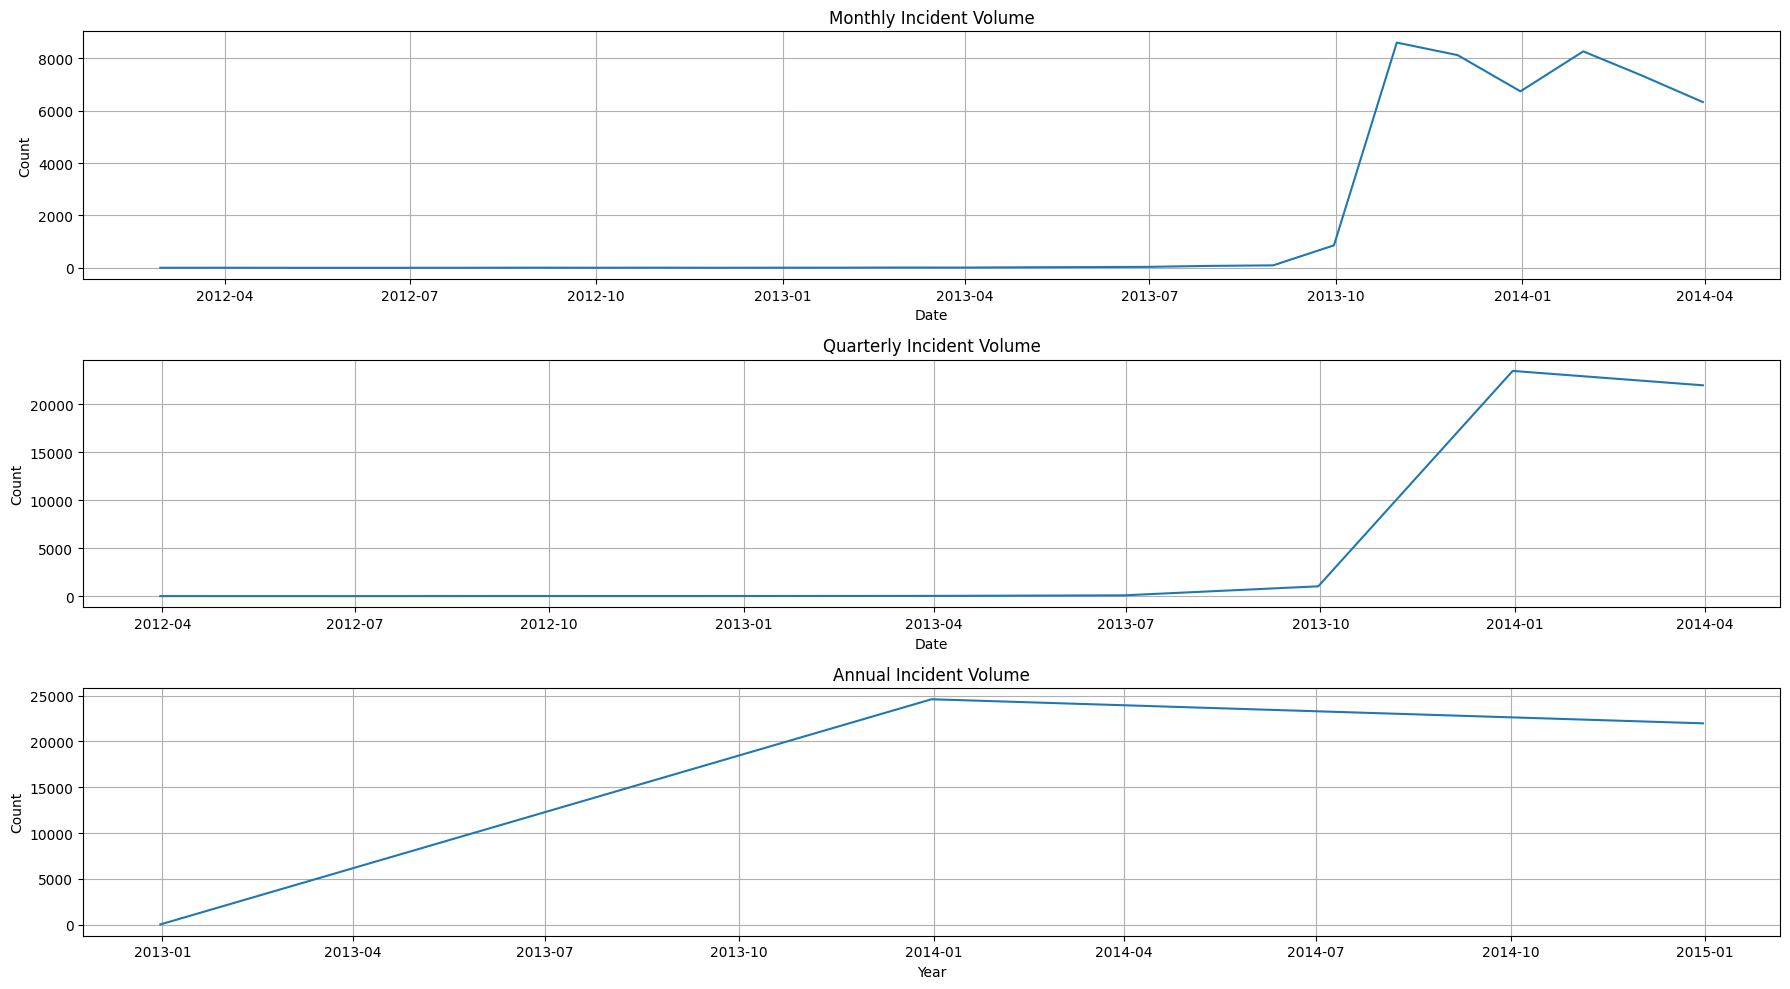

In [353]:
# Create one figure with 3 subplots
plt.figure(figsize=(18, 10))

# 1. Monthly plot
plt.subplot(3, 1, 1)
plt.plot(monthly_counts)
plt.title("Monthly Incident Volume")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)

# 2. Quarterly plot
plt.subplot(3, 1, 2)
plt.plot(quarterly_counts)
plt.title("Quarterly Incident Volume")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)

# 3. Yearly plot
plt.subplot(3, 1, 3)
plt.plot(annual_counts)
plt.title("Annual Incident Volume")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()

##### Monthly-
###### From 2012–2013 -> almost no incident,
###### From 2013-2014 -> sudden big rise (8000+,7000+,etc)


##### Quaterly-
###### Same behaviour but more Aggregated

##### Anuanly-
###### Show a simple rise fall pattern


In [354]:
df.index.year.value_counts().sort_index()

Open_Time
2012       21
2013    24606
2014    21979
Name: count, dtype: int64

##### 2012 has 21 incidents means 1-2/months
##### 2013   -> 24606
##### 2014   -> 21979

#### 21 incidents total = useless + noisy + will confuse the model.

In [355]:
df = df[df.index.year >= 2013]

In [356]:
monthly_counts = df.resample("M").size()       #"M" = group by Month

# quarterly_counts = df.resample("Q").size() # "Q" = group by Quarter (Jan–Mar = Q1, etc.)

# annual_counts = df.resample("Y").size()# "Y" = group by Year


# Visualize

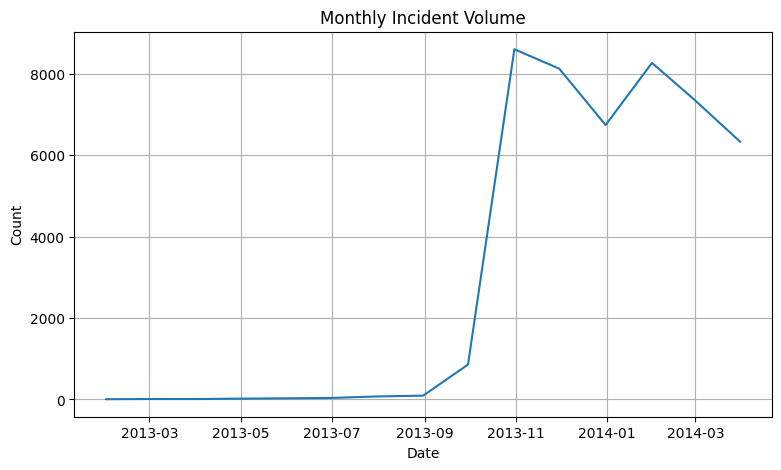

In [358]:
plt.figure(figsize=(9,5))
plt.plot(monthly_counts)
plt.title("Monthly Incident Volume")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)

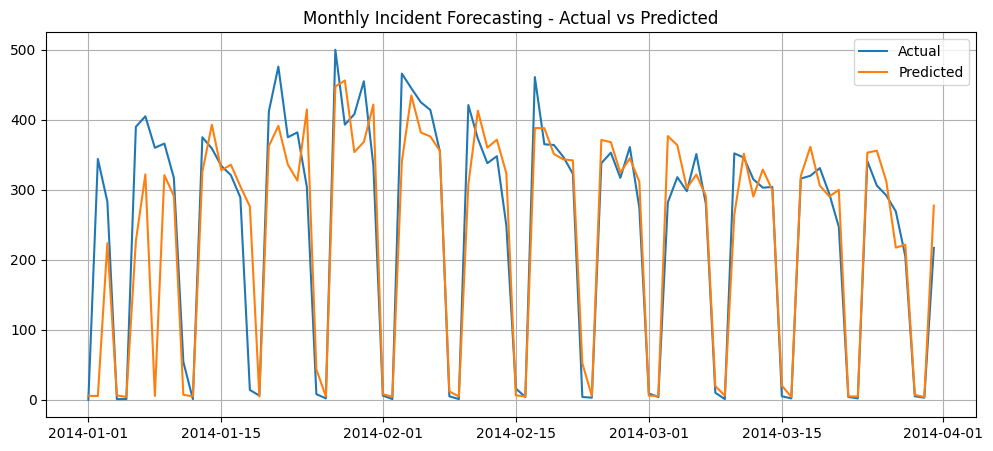

In [359]:
daily_counts = df.resample("D").size()       #"D" = group by Daily
df_ts = daily_counts.to_frame(name="count")

df_ts["lag_1"] = df_ts["count"].shift(1)
df_ts["lag_7"] = df_ts["count"].shift(7)
df_ts["lag_30"] = df_ts["count"].shift(30)

df_ts["rolling_7"] = df_ts["count"].rolling(7).mean()
df_ts["rolling_30"] = df_ts["count"].rolling(30).mean()

df_ts = df_ts.dropna()

# -----------------------------
from sklearn.ensemble import RandomForestRegressor

X = df_ts.drop("count", axis=1)
y = df_ts["count"]

X_train = X.loc["2013"]
y_train = y.loc["2013"]

X_test = X.loc["2014"]
y_test = y.loc["2014"]

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)
# -----------------------------

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.legend()
plt.title("Monthly Incident Forecasting - Actual vs Predicted")
plt.grid(True)
plt.show()


# Improve Daily Forecasting Model

In [360]:
daily_counts = df.resample("D").size()
df_ts = daily_counts.to_frame(name="count")


df_ts["rolling_mean_7"] = df_ts["count"].rolling(7).mean()
df_ts["rolling_mean_30"] = df_ts["count"].rolling(30).mean()

df_ts["rolling_std_7"] = df_ts["count"].rolling(7).std()
df_ts["rolling_std_30"] = df_ts["count"].rolling(30).std()


# Add Rolling Window Features

In [361]:
df_ts["rolling_mean_7"] = df_ts["count"].rolling(7).mean()
df_ts["rolling_mean_30"] = df_ts["count"].rolling(30).mean()

df_ts["rolling_std_7"] = df_ts["count"].rolling(7).std()
df_ts["rolling_std_30"] = df_ts["count"].rolling(30).std()


# Add Date-Based Features

In [362]:
df_ts["day_of_week"] = df_ts.index.dayofweek
df_ts["is_weekend"] = (df_ts.index.dayofweek >= 5).astype(int)
df_ts["month"] = df_ts.index.month
df_ts["quarter"] = df_ts.index.quarter
df_ts["year"] = df_ts.index.year

In [363]:
df_ts = df_ts.dropna()


# Split into TRAIN (2013) and TEST (2014)

In [364]:
train = df_ts.loc["2013"]
test  = df_ts.loc["2014"]

X_train = train.drop("count", axis=1)
y_train = train["count"]

X_test = test.drop("count", axis=1)
y_test = test["count"]


# Train a Better Model

In [365]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
pred_daily = model.predict(X_test)


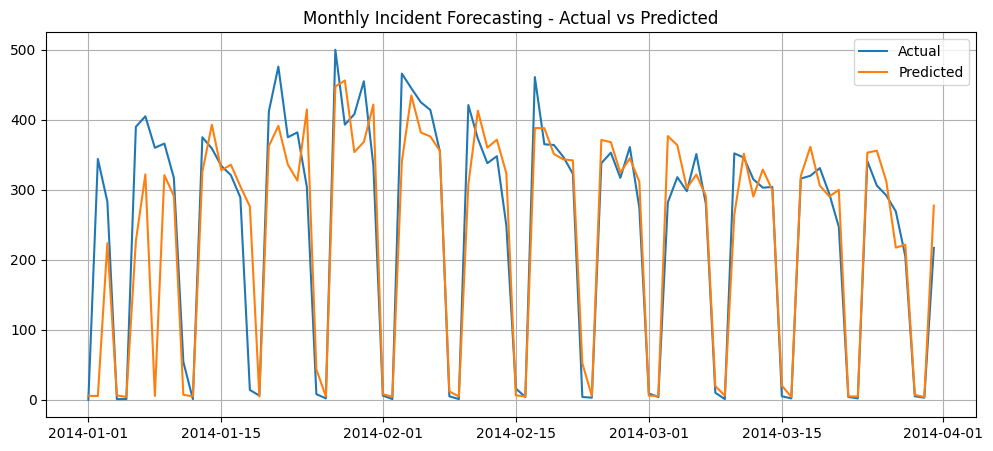

In [366]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, pred, label="Predicted")
plt.legend()
plt.title("Monthly Incident Forecasting - Actual vs Predicted")
plt.grid(True)
plt.show()


# Convert DAILY Predictions → Monthly Forecasts

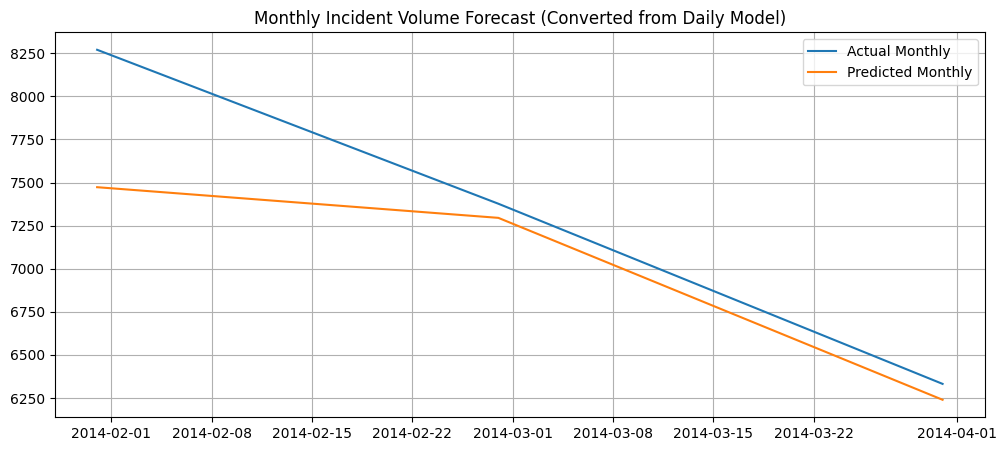

In [368]:
pred_series = pd.Series(pred_daily, index=y_test.index)

monthly_pred = pred_series.resample("M").sum()
monthly_actual = y_test.resample("M").sum()


plt.figure(figsize=(12,5))
plt.plot(monthly_actual.index, monthly_actual, label="Actual Monthly")
plt.plot(monthly_pred.index, monthly_pred, label="Predicted Monthly")
plt.title("Monthly Incident Volume Forecast (Converted from Daily Model)")
plt.legend()
plt.grid(True)
plt.show()

#  The Final Pipelinne

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

def evaluate_model(y_true, y_pred, model_name=None):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    smape_val = smape(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "MAPE (%)": round(mape, 3),
        "SMAPE (%)": round(smape_val, 3)
    }


## monthly only for forecasting.

In [ ]:
monthly_counts = df.resample("M").size()


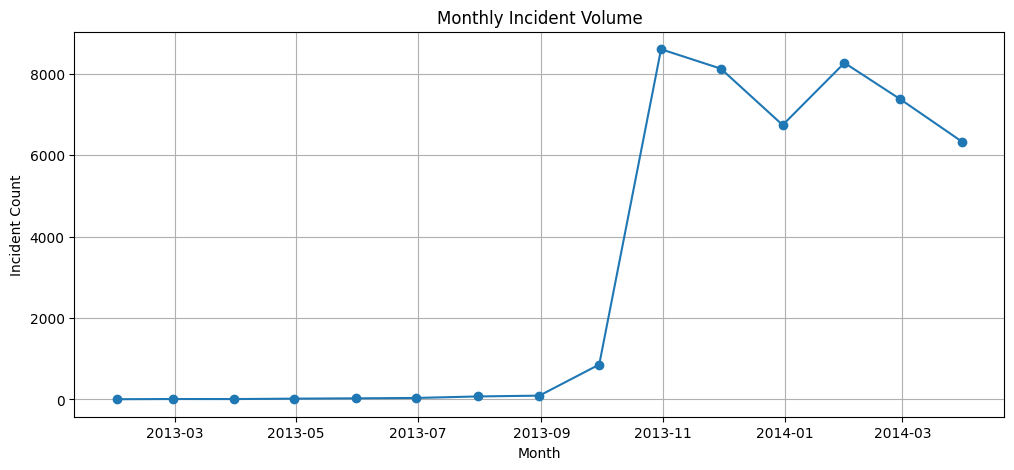

In [377]:
plt.figure(figsize=(12,5))
plt.plot(monthly_counts, marker='o')
plt.title("Monthly Incident Volume")
plt.xlabel("Month")
plt.ylabel("Incident Count")
plt.grid(True)
plt.show()


## lag features on monthly

In [ ]:
df_ts = monthly_counts.to_frame("count")
df_ts["lag_1"] = df_ts["count"].shift(1)
df_ts["lag_3"] = df_ts["count"].shift(3)
df_ts["lag_6"] = df_ts["count"].shift(6)
df_ts["rolling_3"] = df_ts["count"].rolling(3).mean()
df_ts["rolling_6"] = df_ts["count"].rolling(6).mean()

df_ts = df_ts.dropna()


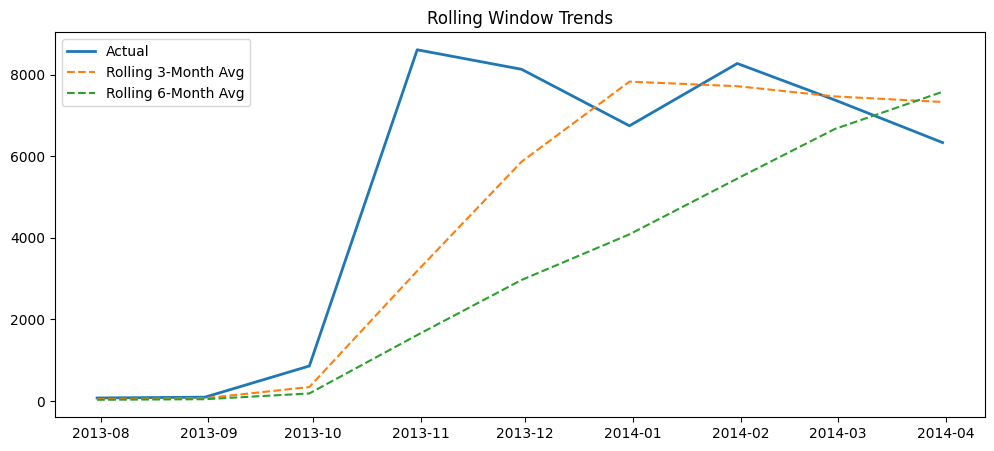

In [378]:
plt.figure(figsize=(12,5))
plt.plot(df_ts['count'], label='Actual', linewidth=2)
plt.plot(df_ts['rolling_3'], label='Rolling 3-Month Avg', linestyle='--')
plt.plot(df_ts['rolling_6'], label='Rolling 6-Month Avg', linestyle='--')
plt.title("Rolling Window Trends")
plt.legend()
plt.show()


## Train/Test split using MONTHLY data

In [ ]:
X = df_ts.drop("count", axis=1)
y = df_ts["count"]

X_train = X.iloc[:-3]
y_train = y.iloc[:-3]

X_test = X.iloc[-3:]
y_test = y.iloc[-3:]


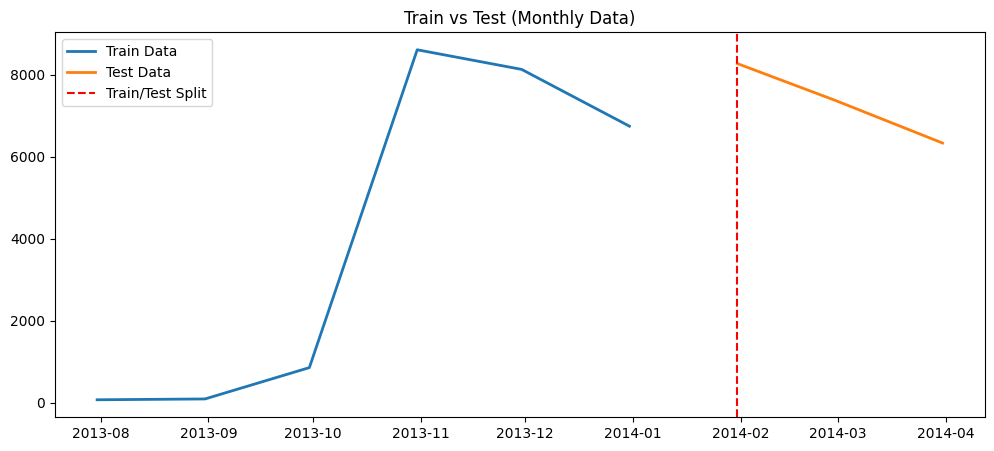

In [379]:
plt.figure(figsize=(12,5))
plt.plot(y_train, label='Train Data', linewidth=2)
plt.plot(y_test, label='Test Data', linewidth=2)
plt.axvline(y_test.index[0], color='red', linestyle='--', label='Train/Test Split')
plt.title("Train vs Test (Monthly Data)")
plt.legend()
plt.show()


## XGBoost on monthly data

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)


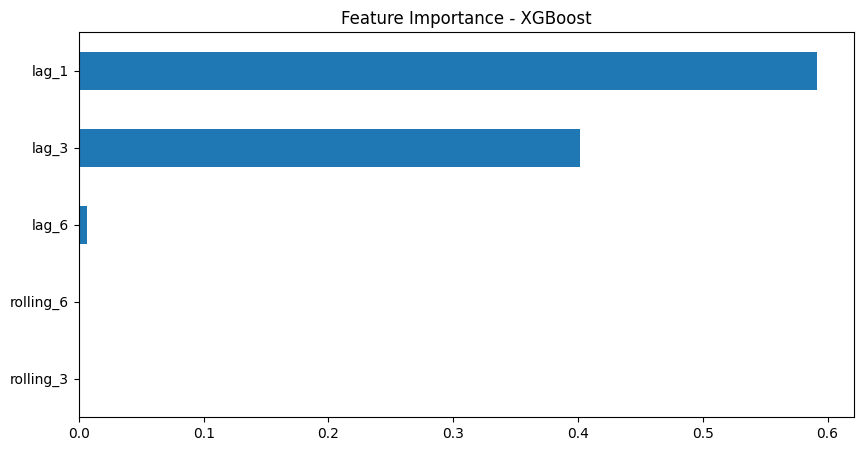

In [381]:


feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10,5))
plt.title("Feature Importance - XGBoost")
plt.show()


## Evaluate (SAFE evaluation for monthly)

In [ ]:
evaluate_model(y_test, pred_xgb, "XGBoost")


{'Model': 'XGBoost',
 'MAE': 857.302,
 'RMSE': np.float64(871.787),
 'MAPE (%)': np.float64(11.857),
 'SMAPE (%)': np.float64(11.88)}

NameError: name 'future_pred_series' is not defined

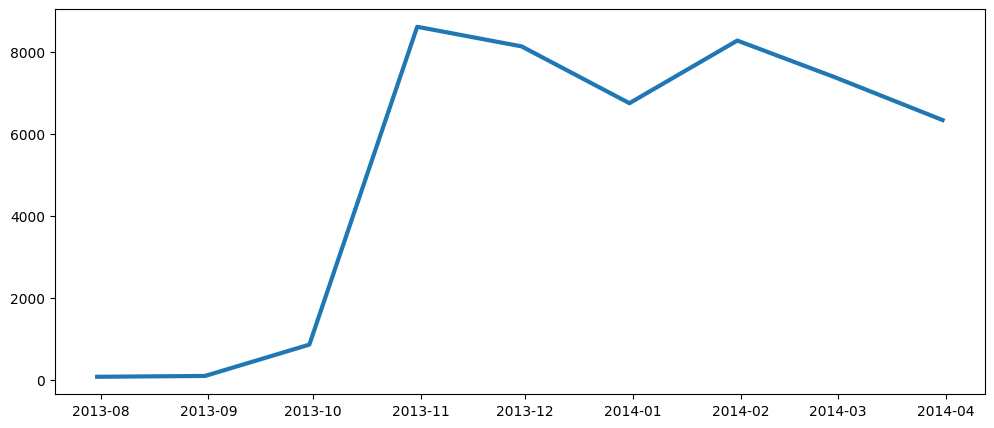

In [382]:
plt.figure(figsize=(12,5))
plt.plot(y, label="Historical", linewidth=3)
plt.plot(future_pred_series, label="Forecast", linewidth=3, linestyle="--")
plt.title("Future Monthly Incident Forecast")
plt.legend()
plt.grid(True)
plt.show()

